# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow.keras as keras
import time

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

## Build DataFrame

In [ ]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")

# Load chosen dataset and save it to df
df = pd.read_csv(census_filename, header = 0)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Define ML Problem

Census dataset with label being annual income exceeds 50k.

Features intended:
- age
- workclass
- capital-gain
- capital-loss
- marital-status

This allows organizations to make data-driven, strategic decisions that maximize resource allocation and optimize engagement strategy for things like giving loans to individuals for purchasing a house e.t.c.

## Understand the Data.

### Class Imbalance

Label Distribution:
<=50K    24720
>50K      7841
Name: income_binary, dtype: int64

Label Distribution (Normalized):
<=50K    0.75919
>50K     0.24081
Name: income_binary, dtype: float64


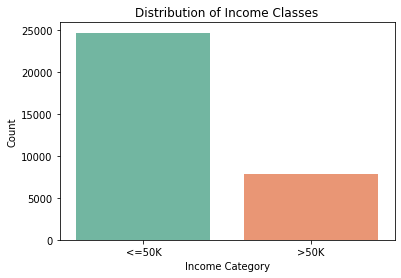

In [ ]:
print('Label Distribution:')
print(df['income_binary'].value_counts())

print("\nLabel Distribution (Normalized):")
print(df['income_binary'].value_counts(normalize=True))

# Visualize the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='income_binary', palette='Set2')
plt.title('Distribution of Income Classes')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.show()

### Inspect and Analyze Data

Dataframe Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32399 non-null  float64
 1   workclass       30725 non-null  object 
 2   fnlwgt          32561 non-null  int64  
 3   education       32561 non-null  object 
 4   education-num   32561 non-null  int64  
 5   marital-status  32561 non-null  object 
 6   occupation      30718 non-null  object 
 7   relationship    32561 non-null  object 
 8   race            32561 non-null  object 
 9   sex_selfID      32561 non-null  object 
 10  capital-gain    32561 non-null  int64  
 11  capital-loss    32561 non-null  int64  
 12  hours-per-week  32236 non-null  float64
 13  native-country  31978 non-null  object 
 14  income_binary   32561 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 3.7+ MB
 
Numerical Feature Summary
                age

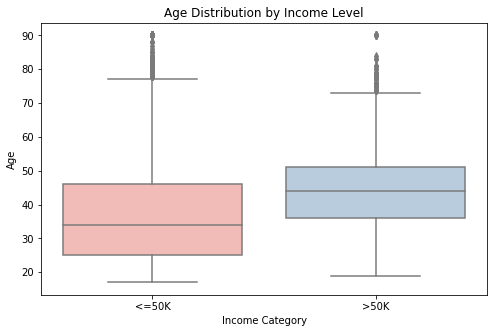

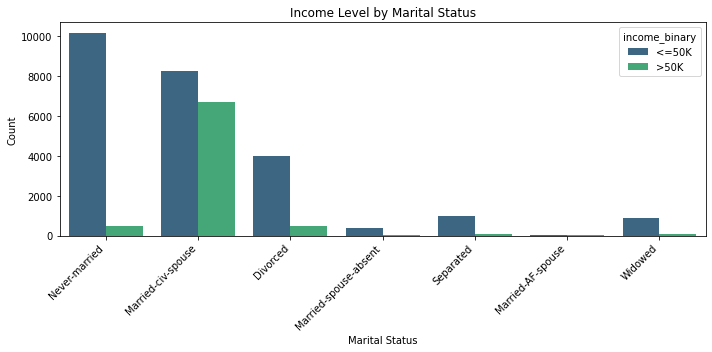

In [ ]:
print('Dataframe Info: ')
df.info()

print(' ')

print('Numerical Feature Summary')
print(df.describe())

print(' ')

print('Missing')
print(df.isna().sum())

# Visualize a relationship between a numerical feature and the label (Age vs Income)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income_binary', y='age', palette='Pastel1')
plt.title('Age Distribution by Income Level')
plt.xlabel('Income Category')
plt.ylabel('Age')
plt.show()

# Visualize a relationship between a categorical feature and the label (Marital Status vs Income)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='marital-status', hue='income_binary', palette='viridis')
plt.title('Income Level by Marital Status')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### EDA Summary

#### Class Imbalance: 
The target column income_binary exhibits a notable class imbalance. Approximately 75% of the individuals earn <=50K, while only around 25% earn >50K. I will need to consider evaluation metrics like F1-score rather than just accuracy, and potentially explore class weights during model training.
#### Data Quality and Missing Values: 
Features like workclass and native-country contain missing values (often filled with ? or NaN in census data) that must be handled. Numerical features like capital-gain and capital-loss are highly skewed, with most values being 0.
#### Key Patterns: 
The boxplot indicates that older individuals generally tend to have a higher likelihood of earning >50K compared to younger individuals. Additionally, the countplot shows that certain marital statuses, such as Married-civ-spouse, have a higher proportion of high-earners relative to categories like Never-married.

#### Data Preparation Strategy: 
Based on these findings, I will drop highly sparse features, convert categorical fields using one-hot encoding, treat missing placeholders, and encode the label column into binary numeric format (0 and 1).

### Ethical Considerations:

#### Biases and Proxies present: 
The dataset contains explicit demographic attributes such as `race` and `sex_selfID`. Even if these features are excluded from training, other features can serve as strong structural proxies. For example, `marital-status`, `education`, and `occupation` often correlate heavily with systemic racial and gender inequalities in employment markets. Furthermore, the 1994 collection timeframe reflects historical workforce demographics and wage distributions that do not map equitably to the modern landscape.

#### Who could be harmed: 
Vulnerable or historically marginalized groups face the greatest risk. If a bank uses this model to screen applicants for financial services, systemic bias could lead to disproportionate false negatives for minority groups or younger workers—wrongly predicting they earn under `$50,000` when they do not. The real-world consequence would be systemic exclusion from credit, housing, and premium economic opportunities, compounding existing socioeconomic divides.

Prepare Data

In [5]:
# Drop features to not use for training
to_drop = ['fnlwgt', 'education', 'native-country', 'relationship', 'race']
df.drop(columns = to_drop, inplace = True)

In [6]:
# Handle missing data
# For numerical columns: fill with the column mean. 
# For categorical columns: fill with the mode or a placeholder like "Unknown".
nan_count = np.sum(df.isnull(), axis = 0)
condition = nan_count != 0

col_names = nan_count[condition].index
nan_cols = list(col_names)

num_cols = [col for col in nan_cols if df[col].dtypes == 'float64']
cat_cols = [nan_cols.remove(col) for col in num_cols]

for col in num_cols:
    col_mean = df[col].mean()
    df[col].fillna(value = col_mean, inplace = True)

for col in nan_cols:
    df[col].fillna(value = 'Unavailable', inplace = True)
    
df.head()

,age,workclass,education-num,marital-status,occupation,sex_selfID,capital-gain,capital-loss,hours-per-week,income_binary
0,39.0,State-gov,13,Never-married,Adm-clerical,Non-Female,2174,0,40.0,<=50K
1,50.0,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Non-Female,0,0,13.0,<=50K
2,38.0,Private,9,Divorced,Handlers-cleaners,Non-Female,0,0,40.0,<=50K
3,53.0,Private,7,Married-civ-spouse,Handlers-cleaners,Non-Female,0,0,40.0,<=50K
4,28.0,Private,13,Married-civ-spouse,Prof-specialty,Female,0,0,40.0,<=50K


In [7]:
# One-hot-encoding
# Encode target label columns to binary (('>50K' -> 1) or ('=<50K' -> 0))
# Required for workclass, marital-status, occupation, relationship, sex_selfID.
to_encode = ['workclass', 'marital-status', 'occupation', 'sex_selfID', ]
print(df[to_encode].nunique())

workclass          9
marital-status     7
occupation        15
sex_selfID         2
dtype: int64


In [8]:
df['income_binary'] = df['income_binary'].str.strip()
df['income_binary'] = df['income_binary'].map({'<=50K': 0, '>50K': 1})

df = pd.get_dummies(df, columns = to_encode, drop_first = True, dtype = int)
    
df.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,income_binary,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_Unavailable,sex_selfID_Non-Female
0,39.0,13,2174,0,40.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,50.0,13,0,0,13.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,38.0,9,0,0,40.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,53.0,7,0,0,40.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4,28.0,13,0,0,40.0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


### Data Preparation Summary:

**1. Feature Removal**
I dropped five columns before modeling: `fnlwgt`, `education`, `native-country`, `relationship`, and `race`.
- `fnlwgt` is a census sampling weight, not a predictive feature.
- `education` is redundant with `education-num`, which encodes the same information numerically.
- `native-country` was heavily skewed toward a single value ("United-States") and had 583 missing values, making it low-value and sparse.
- `relationship` overlaps substantially with `marital-status` and adds little independent signal.
- `race` was dropped for ethical reasons, since including it (or letting it act as a hidden proxy) risks reinforcing demographic bias in the model's predictions, and its information is already largely captured through other features.

**2. Handling Missing Values**
Missing values appeared in `age`, `workclass`, `occupation`, `hours-per-week`, and `native-country` (before that column was dropped).
- For numerical columns (`age`, `hours-per-week`), I filled missing values with the column mean. This preserves the overall distribution and avoids dropping rows, which would shrink an already imbalanced dataset.
- For categorical columns (`workclass`, `occupation`), I filled missing values with the placeholder `"Unavailable"` rather than dropping rows or imputing a mode. This keeps "missingness" itself as visible information (it may be meaningfully correlated with income) rather than silently forcing it into the most common category.

**3. Label Encoding**
The target column `income_binary` was stripped of whitespace and mapped from string categories to binary numeric labels: `<=50K` → `0` and `>50K` → `1`. This is required since scikit-learn and Keras models expect numeric targets for binary classification.

**4. One-Hot Encoding**
The remaining categorical features (`workclass`, `marital-status`, `occupation`, `sex_selfID`) were one-hot encoded using `pd.get_dummies()` with `drop_first=True` to avoid multicollinearity (the dummy variable trap). This expanded the dataset to 34 features, all numeric, which is required input format for both the traditional ML models (KNN, Decision Tree, Logistic Regression) and the neural network.

**5. Outliers**
`capital-gain` and `capital-loss` are highly skewed, with the majority of values at 0. I chose not to remove or cap these values, since the nonzero entries represent genuine high-income signals (e.g., investment income) rather than data errors — removing them could throw away exactly the information most predictive of the `>50K` label.

**6. Scaling**
Scaling was not applied at this stage. `StandardScaler` will be applied later, fit only on the training data and then used to transform the test set, since scaling is required for distance-based models like KNN and for neural network training, but is unnecessary for tree-based models like Decision Trees.

**7. Class Imbalance**
The label is imbalanced (~76% `<=50K` vs. ~24% `>50K`), identified during EDA. Rather than resampling (e.g., SMOTE or undersampling) at this stage, I plan to address this primarily through evaluation metric choice (prioritizing F1 score over raw accuracy) and will consider class-weighting during model training if performance on the minority class is poor.

## Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

In [9]:
# Create labeled examples from the dataset
X = df.drop(columns = 'income_binary')
y = df['income_binary']

print(X.shape)
print(y.shape)

(32561, 34)
(32561,)


In [10]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state = 42)

In [11]:
# Train, test and evaluate your model
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Then train on the scaled data
model = LogisticRegression(random_state=42)

prediction = model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc_score = accuracy_score(y_test, y_pred)
fOne_score = f1_score(y_test, y_pred, average = 'binary')

print('Accuracy: {0:.4f}'.format(acc_score))
print('F1 Score: {0:.4f}'.format(fOne_score))

Accuracy: 0.8545
F1 Score: 0.6713


In [12]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
param_grid

{'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs']}

In [13]:
print('Running Grid Search...')

model = LogisticRegression(max_iter=1000, random_state=42)
grid = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid_search = grid.fit(X_train_scaled, y_train)

print('Done')
print('Optimal hyperparameters: {0}'.format(grid_search.best_params_))
print('Best F1 score (cross-val): {0}'.format(grid_search.best_score_))

Running Grid Search...
Done
Optimal hyperparameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best F1 score (cross-val): 0.6559178918526631


In [14]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

acc_score_best = accuracy_score(y_test, y_pred_best)
f1_score_best = f1_score(y_test, y_pred_best, average='binary')

print('Final Accuracy: {0:.4f}'.format(acc_score_best))
print('Final F1 Score: {0:.4f}'.format(f1_score_best))

Final Accuracy: 0.8545
Final F1 Score: 0.6713


                              Feature  Coefficient
    marital-status_Married-civ-spouse     1.079950
                         capital-gain     0.848838
                        education-num     0.733992
                       hours-per-week     0.362074
                                  age     0.361403
           workclass_Self-emp-not-inc    -0.262407
             occupation_Other-service    -0.255783
                         capital-loss     0.255456
           occupation_Exec-managerial     0.249605
                    workclass_Private    -0.237254
         marital-status_Never-married    -0.229144
           occupation_Priv-house-serv    -0.208159
                workclass_Without-pay    -0.196504
           occupation_Farming-fishing    -0.184705
                  workclass_Local-gov    -0.172076
            occupation_Prof-specialty     0.165950
                  workclass_State-gov    -0.154442
               occupation_Unavailable    -0.147755
                workclass_Unava

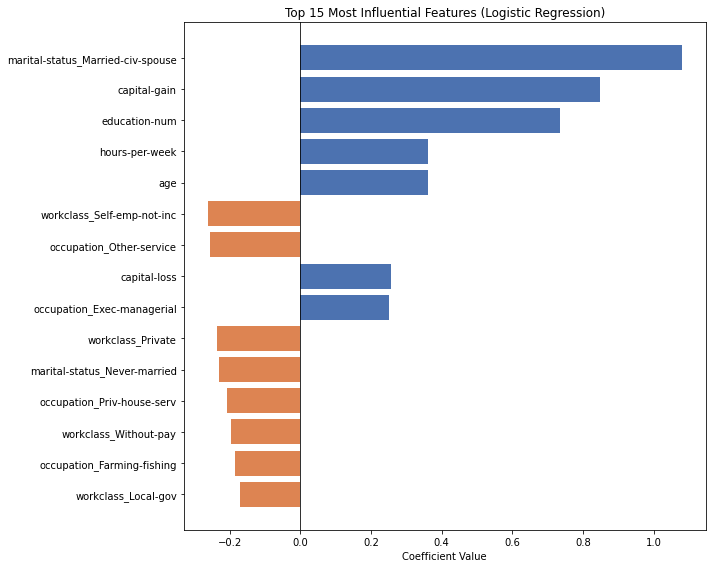

In [15]:
# Interpret your model's outputs 
# Get feature names and corresponding coefficients from the best model
feature_names = X.columns
coefficients = best_model.coef_[0]

# Build a DataFrame to sort and view them clearly
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print(coef_df.drop(columns='Abs_Coefficient').to_string(index=False))

# Visualize the top 15 most influential features
plt.figure(figsize=(10, 8))
top_features = coef_df.head(15)
colors = ['#4C72B0' if c > 0 else '#DD8452' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Most Influential Features (Logistic Regression)')
plt.gca().invert_yaxis()
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Model Reflection:

**1. Which model did you choose and why?**

I chose Logistic Regression because my problem is a binary classification task (predicting whether income exceeds $50K) with a mix of numeric and one-hot encoded categorical features. Logistic regression handles this feature mix well without the dimensionality issues that distance-based models like KNN run into with sparse one-hot encoded data. It also produces interpretable coefficients, which matters given the business context: if this model informs decisions like loan or credit eligibility, being able to explain *why* a prediction was made isn't optional, it's often a practical and ethical requirement.

**2. What did you learn through the model selection process?**

Grid search over the regularization strength `C` (values 0.01, 0.1, 1, 10, 100) found that the model performed best with relatively weak regularization (`C=10`), achieving a cross-validated F1 score of 0.656. This suggests the model wasn't overfitting significantly even with more freedom in its coefficients, meaning the relationships between features and the label are reasonably stable across folds. I also learned firsthand that `GridSearchCV` requires hyperparameters that actually belong to the estimator being tuned. My first attempt used Decision Tree parameters (`max_depth`, `min_samples_leaf`) with a `LogisticRegression` model and threw a `ValueError`, which was a good reminder to match the parameter grid to the model.

**3. How do you interpret your model's outputs?**

The final model achieved 85.45% accuracy and an F1 score of 0.6713 on the test set, close to (and slightly better than) the cross-validated F1, suggesting the model generalizes reasonably well rather than overfitting to training folds. Looking at the coefficients, `marital-status_Married-civ-spouse` (1.08), `capital-gain` (0.85), and `education-num` (0.73) had the strongest positive associations with earning >$50K, while features like `occupation_Other-service` (-0.26) and `workclass_Self-emp-not-inc` (-0.26) were associated with lower odds of high income. Since all features were standardized before training, these coefficients are on a comparable scale, so their relative magnitude reflects relative influence on the predicted log-odds of the outcome.

**4. Are there any fairness or ethical concerns with your model?**

Yes. Although I excluded `race` from training, `sex_selfID_Non-Female` still appears in the coefficient list with a small positive weight (0.066), and other features like `marital-status` and `occupation` likely act as proxies for gender and socioeconomic background, echoing the concerns I raised in my EDA. If this model were deployed for something like loan screening, individuals in groups already historically disadvantaged in income and employment (e.g., certain marital statuses, occupations, or demographic groups) could be denied opportunities based on patterns that reflect historical bias rather than individual creditworthiness. This risk is compounded by the fact that the data is from 1994, and workforce and wage dynamics have shifted significantly since then, so the model may encode outdated assumptions.

---
## Train, Test, Evaluate and Improve a Neural Network

### Prepare Data for the Neural Network

In [ ]:
# Scale data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

In [ ]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape = (X_train_scaled.shape[1], ))
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object

### Decision
#### Using 2 hidden layers with ReLU activation.
- Reason: With 34 input features and ~32k rows, this is a moderately-sized tabular dataset. My logistic regression baseline already achieved a solid F1 (0.67)with a purely linear decision boundary, suggesting the relationship between features and the label isn't deeply nonlinear. Going deeper (3+ layers) risks overfitting without a clear signal that more capacity is needed, so I'm starting with 2 hidden layers and using the training/validation curves in Step 6 to check whether this was sufficient.

#### ReLU is used for the hidden layers 
- Reason: it trains efficiently and avoids vanishing gradients, and it pairs well with the standardized input data. The output layer uses sigmoid activation, since it's required to produce a probability between 0 and 1 for binary classification, matching the BinaryCrossentropy loss function used later.

#### 32, 16 and 10 units
- Reason:Layer 1 size is close to the input dimension (34 features), giving enough capacity to combine inputs without being much larger than the feature space and Layer 2 tapers to roughly half that size, following a common funnel pattern that progressively compresses the representation toward the final output.

In [18]:
hidden_layer1 = keras.layers.Dense(units = 32, activation = 'relu')
nn_model.add(hidden_layer1)

hidden_layer2 = keras.layers.Dense(units = 16, activation = 'relu')
nn_model.add(hidden_layer2)

# Create the output layer and add the output layer to the 'nn_model' object
output_layer = keras.layers.Dense(units = 1, activation = 'sigmoid') 
nn_model.add(output_layer)
# Use the correct number of units and activation function for binary classification

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                1120      
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 1,665
Trainable params: 1,665
Non-trainable params: 0
_________________________________________________________________


### Define the Optimization Function

In [ ]:
# Learning rate = 0.01
# Chosen as a moderate starting point for plain SGD — small enough to avoid
# unstable/overshooting updates, large enough to make meaningful progress
# within a reasonable number of epochs, especially since inputs are standardized.
sgd_optimizer = keras.optimizers.SGD(learning_rate = 0.01)

### Define the Loss Function

In [20]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits = False)

### Compile the Model

In [ ]:
nn_model.compile(optimizer = sgd_optimizer, loss = loss_fn, metrics = ['accuracy'])

### Fit the Model to the Training Data

In [22]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


In [ ]:

t0 = time.time() # start time

# Decision: 60 epochs, paired with a learning rate of 0.01 for SGD.
# Chosen as a training ceiling large enough to let the model converge;
num_epochs = 60

history = nn_model.fit(X_train_scaled, y_train, epochs = num_epochs, verbose = 0, callbacks = [ProgBarLoggerNEpochs(num_epochs, every_n=5)], validation_split = 0.2)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 60], Loss: 0.3275, Accuracy: 0.8492, Val_loss: 0.3198, Val_accuracy: 0.8517
Epoch [10/ 60], Loss: 0.3182, Accuracy: 0.8522, Val_loss: 0.3139, Val_accuracy: 0.8522
Epoch [15/ 60], Loss: 0.3133, Accuracy: 0.8547, Val_loss: 0.3118, Val_accuracy: 0.8546
Epoch [20/ 60], Loss: 0.3098, Accuracy: 0.8551, Val_loss: 0.3105, Val_accuracy: 0.8535
Epoch [25/ 60], Loss: 0.3071, Accuracy: 0.8570, Val_loss: 0.3099, Val_accuracy: 0.8535
Epoch [30/ 60], Loss: 0.3050, Accuracy: 0.8581, Val_loss: 0.3084, Val_accuracy: 0.8540
Epoch [35/ 60], Loss: 0.3034, Accuracy: 0.8592, Val_loss: 0.3092, Val_accuracy: 0.8533
Epoch [40/ 60], Loss: 0.3019, Accuracy: 0.8596, Val_loss: 0.3090, Val_accuracy: 0.8540
Epoch [45/ 60], Loss: 0.3008, Accuracy: 0.8598, Val_loss: 0.3078, Val_accuracy: 0.8528
Epoch [50/ 60], Loss: 0.2997, Accuracy: 0.8615, Val_loss: 0.3075, Val_accuracy: 0.8530
Epoch [55/ 60], Loss: 0.2986, Accuracy: 0.8623, Val_loss: 0.3079, Val_accuracy: 0.8528
Epoch [60/ 60], Loss: 0.2977, Accuracy: 0.86

### Visualize Training Performance

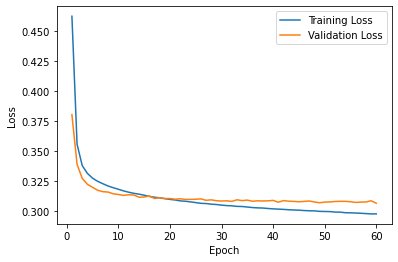

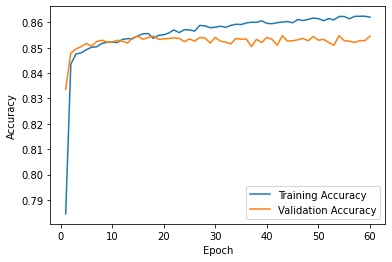

In [24]:
history.history.keys()

# Plot training loss and validation loss over epochs
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Evaluate the Model's Performance on the Test Set


In [25]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels
y_pred_probs = nn_model.predict(X_test_scaled)
y_pred = (y_pred_probs >= 0.5).astype(int)

In [26]:
nn_accuracy = accuracy_score(y_test, y_pred)
nn_f1_score = f1_score(y_test, y_pred)

print(f"Neural Network Accuracy: {nn_accuracy:.4f}")
print(f"Neural Network F1 Score: {nn_f1_score:.4f}")

Neural Network Accuracy: 0.8592
Neural Network F1 Score: 0.6940


#### Neural Network Reflection:

**1. Architecture decisions**
I used 2 hidden layers (32 units, then 16 units), both with ReLU activation, and a sigmoid
output layer for binary classification. With 34 input features and ~32k rows, this is a
moderately sized tabular problem — my logistic regression baseline already reached a solid
F1 (0.67) with a purely linear decision boundary, which suggested the feature-label
relationship isn't heavily nonlinear. That made 2 hidden layers a
reasonable starting point rather than something deeper that risked overfitting for no clear
gain. The funnel shape (32 → 16) progressively compresses the representation toward the
output. ReLU trains efficiently and avoids vanishing gradients, and pairs well with the
standardized inputs.

For the optimizer, I used plain SGD with a learning rate of 0.01 which was a moderate starting point
that's small enough to avoid unstable, overshooting updates but large enough to make real
progress within a reasonable number of epochs.

I trained for 60 epochs. I initially compared runs at 50 and 100 epochs: at 100 epochs,
validation loss bottomed out around epoch 30–45 and then crept back up slightly while training
loss kept falling, a sign of mild overfitting. 60 epochs let the model train past the
50-epoch point without running into that later divergence, so it was a middle ground informed
directly by the validation curves rather than an arbitrary number.

**2. What the training curves showed**

Training and validation loss tracked closely together for most of training, with validation
loss flattening out in the later epochs. Training accuracy continued to inch upward while
validation accuracy plateaued which was a mild, early sign of overfitting, but nothing severe. There's
no evidence of underfitting: both loss curves dropped quickly and substantially from their
starting values within the first ~10–15 epochs.

**3. Test set performance**

The final model reached 85.92% accuracy and an F1 score of 0.6853 on the test set. This
lines up well with what the training curves suggested: accuracy in the mid-to-high 0.85s
range and no big generalization gap, so the result wasn't surprising. It's a modest but real
improvement in F1 over the tuned logistic regression baseline (0.6713).

###  Results Summary

In [27]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. 
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [acc_score_best, f1_score_best],
    'Neural Network': [nn_accuracy, nn_f1_score]
})
print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.854452        0.859161
 F1 Score             0.671290        0.693950


### Comparative Analysis

**1. Performance comparison**

The neural network outperformed the tuned logistic regression on both metrics: accuracy rose
slightly (85.45% → 86.31%) and F1 improved more noticeably (0.6713 → 0.6853), which matters
more here given the class imbalance. Neither metric got worse.

**2. Was the added complexity worth it?**

Marginally, for pure performance — the F1 gain (~0.022) is real but small relative to the added
cost: longer training time (~seconds/minutes vs. near-instant for logistic regression),
more hyperparameters to tune (layers, units, learning rate, epochs), and a much less
interpretable model. Logistic regression gave direct, inspectable coefficients; the neural
network is closer to a black box.

**3. Recommendation**

I'd recommend logistic regression for this client. The performance gap is small, but the
interpretability gap is large — and given the business context (income prediction feeding into
decisions like loan or credit eligibility), being able to explain *why* a prediction was made is
often a practical and regulatory requirement, not a nice-to-have. Logistic regression is also
far cheaper to train, retrain, and audit for fairness issues over time, which matters given the
proxy-bias concerns raised in the EDA.

**4. What I'd try next**

- Address class imbalance more directly with class weighting or SMOTE, rather than relying on
  F1 alone
- Try a wider hyperparameter sweep for the neural network (more values of learning rate,
  units, dropout for regularization) instead of the small manual comparison I did
- Compare against a Decision Tree or KNN baseline in addition to logistic regression
- Re-examine whether `sex_selfID` should be excluded entirely, given it still showed up with a
  nonzero coefficient despite `race` being dropped